# ¿Dónde está mirando el modelo? 

### Heatmap Grad-CAM 

Este notebook sirve para **visualizar en qué zona de la cara** se fija la
CNN al predecir el rango etario, usando la técnica **Grad-CAM** (Gradient-weighted Class
Activation Mapping).

Reutiliza el mismo pipeline balanceado por **edad y etnia** del notebook `4to_analisis.ipynb`
(5 segmentos: niños, jóvenes, adulto joven, adulto, adulto mayor) y entrena un modelo en
**PyTorch** y otro en **Keras** para generar el mapa de calor con cada framework.


# Desarrollo 

### 1. Preparación de los datos

Mismo armado balanceado que en `4to_analisis.ipynb`.

In [1]:
# --- Configuración general ---
import os
import re
import glob
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

DATA_DIR = "./UTKFace_data/UTKFace"     # carpeta única con todas las imágenes (sin subcarpetas por clase)
IMG_SIZE = 64                          # tamaño al que se redimensionan las imágenes
BATCH_SIZE = 32
SEED = 42

np.random.seed(SEED)

In [2]:
# --- Definición de los segmentos etarios y utilidades ---
CLASS_NAMES = ["niños", "jóvenes", "adulto joven", "adulto", "adulto mayor"]

# Códigos de etnia de UTKFace (campo 3 del nombre de archivo).
# 'Others' (código 4) se EXCLUYE del entrenamiento: agrupa etnias muy distintas entre sí
# (incluye hispanos/latinos) y no aporta una categoría étnica consistente para el balanceo.
RACE_NAMES = {0: "White", 1: "Black", 2: "Asian", 3: "Indian"}

def age_to_segment(age: int) -> int:
    """Convierte una edad entera al índice de segmento (0-4) según los nuevos rangos."""
    if age <= 18:
        return 0  # niños
    elif age <= 30:
        return 1  # jóvenes
    elif age <= 45:
        return 2  # adulto joven
    elif age <= 60:
        return 3  # adulto
    else:
        return 4  # adulto mayor

def parse_age_from_filename(filename: str):
    """Extrae la edad desde un nombre de archivo tipo '23_0_1_2017...jpg'. Devuelve None si no calza el formato."""
    base = os.path.basename(filename)
    match = re.match(r"^(\d+)_\d+_\d+_.+\.jpg$", base)
    if match is None:
        return None
    return int(match.group(1))

def parse_race_from_filename(filename: str):
    """Extrae el código de etnia del nombre '[edad]_[genero]_[raza]_[fecha].jpg'.
    Devuelve None si no calza o si la etnia es 'Others' (excluida)."""
    parts = os.path.basename(filename).split("_")
    try:
        race = int(parts[2])
        return race if race in RACE_NAMES else None
    except (ValueError, IndexError):
        return None

In [3]:
# --- Construcción del dataframe desde la carpeta única UTKFace ---
# El segmento etario y la etnia se calculan parseando el NOMBRE DE ARCHIVO (no hay subcarpetas).
# La etnia 'Others' queda excluida (parse_race_from_filename la descarta).
# Balanceo doble: se cuenta cada combinación (segmento, etnia) y se usa el MÍNIMO GLOBAL entre
# todas las combinaciones como cap único -> mismo N° de imágenes por etnia en cada segmento.
all_fps = glob.glob(os.path.join(DATA_DIR, "*.jpg"))
if len(all_fps) == 0:
    raise FileNotFoundError(
        f"No hay imágenes en '{DATA_DIR}'. Revisa que la carpeta UTKFace exista con los .jpg "
        "directamente adentro (ver celda de descarga del dataset)."
    )

records_by_bucket = {(s, r): [] for s in range(len(CLASS_NAMES)) for r in RACE_NAMES}
skipped = 0
for fp in all_fps:
    age = parse_age_from_filename(fp)
    race = parse_race_from_filename(fp)
    if age is None or race is None:
        skipped += 1
        continue
    records_by_bucket[(age_to_segment(age), race)].append(fp)

print(f"Imágenes totales encontradas: {len(all_fps)}  |  Descartadas (nombre inválido o etnia 'Others'/desconocida): {skipped}")
print("Disponibles por (segmento, etnia) antes de balancear:")
counts_tab = pd.DataFrame(
    {RACE_NAMES[r]: [len(records_by_bucket[(s, r)]) for s in range(len(CLASS_NAMES))] for r in RACE_NAMES},
    index=CLASS_NAMES,
)
print(counts_tab)

cap = min(len(fps) for fps in records_by_bucket.values())
print(f"\nCap global (mínimo entre las {len(records_by_bucket)} combinaciones segmento×etnia): {cap}")

rng = np.random.RandomState(SEED)
records = []
for (label_idx, race), fps in records_by_bucket.items():
    sampled = rng.choice(fps, size=cap, replace=False)
    for fp in sampled:
        records.append({"filepath": fp, "label": label_idx, "race": race})

df = pd.DataFrame(records, columns=["filepath", "label", "race"])
print(f"\nImágenes usadas para entrenar (balanceado por edad y etnia): {len(df)}")
print("Por clase:")
print(df["label"].value_counts().sort_index().rename(index=lambda i: CLASS_NAMES[i]))
df.head()

Imágenes totales encontradas: 23708  |  Descartadas (nombre inválido o etnia 'Others'/desconocida): 1695
Disponibles por (segmento, etnia) antes de balancear:
              White  Black  Asian  Indian
niños          2004    320   1014     624
jóvenes        2310   2021   1492    1612
adulto joven   2253   1430    508     922
adulto         1888    446    164     626
adulto mayor   1623    309    256     191

Cap global (mínimo entre las 20 combinaciones segmento×etnia): 164

Imágenes usadas para entrenar (balanceado por edad y etnia): 3280
Por clase:
label
niños           656
jóvenes         656
adulto joven    656
adulto          656
adulto mayor    656
Name: count, dtype: int64


,filepath,label,race
0,./UTKFace_data/UTKFace\16_0_0_2017011023271450...,0,0
1,./UTKFace_data/UTKFace\3_0_0_20170109191321997...,0,0
2,./UTKFace_data/UTKFace\8_1_0_20170109205116937...,0,0
3,./UTKFace_data/UTKFace\16_0_0_2017010401230550...,0,0
4,./UTKFace_data/UTKFace\9_0_0_20170110220238481...,0,0


In [4]:
# --- Split train / val / test (estratificado por clase) ---
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df["label"], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=SEED)

print(f"Train: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}")

Train: 2296  |  Val: 492  |  Test: 492


## 2. Parte A — PyTorch

Entrenamos la CNN en PyTorch para luego aplicarle Grad-CAM.

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

class UTKFaceDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, row["label"]

train_ds = UTKFaceDataset(train_df, transform)
val_ds = UTKFaceDataset(val_df, transform)
test_ds = UTKFaceDataset(test_df, transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

Device: cpu


In [6]:
# --- Arquitectura CNN simple ---
class AgeCNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        # IMG_SIZE=64 -> tras 3 poolings de /2: 64 -> 32 -> 16 -> 8
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)

model_pt = AgeCNN(num_classes=len(CLASS_NAMES)).to(device)
print(model_pt)

AgeCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=5, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


In [7]:
# --- Entrenamiento (PyTorch) ---
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_pt.parameters(), lr=1e-3)
EPOCHS = 10

def run_epoch(model, loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if train:
                optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += imgs.size(0)
    return total_loss / total, correct / total

history_pt = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
t_inicio_pt = time.time()
for epoch in range(EPOCHS):
    tr_loss, tr_acc = run_epoch(model_pt, train_loader, train=True)
    va_loss, va_acc = run_epoch(model_pt, val_loader, train=False)
    history_pt["train_loss"].append(tr_loss); history_pt["train_acc"].append(tr_acc)
    history_pt["val_loss"].append(va_loss); history_pt["val_acc"].append(va_acc)
    print(f"Epoch {epoch+1}/{EPOCHS} | train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | val_loss={va_loss:.4f} val_acc={va_acc:.4f}")
t_total_pt = time.time() - t_inicio_pt

print(f"\nTiempo total de entrenamiento (PyTorch): {t_total_pt:.2f} segundos")

Epoch 1/10 | train_loss=1.5578 train_acc=0.2774 | val_loss=1.4645 val_acc=0.3699
Epoch 2/10 | train_loss=1.3246 train_acc=0.4325 | val_loss=1.2685 val_acc=0.4797
Epoch 3/10 | train_loss=1.2060 train_acc=0.4900 | val_loss=1.1867 val_acc=0.5081
Epoch 4/10 | train_loss=1.1349 train_acc=0.5222 | val_loss=1.1428 val_acc=0.5183
Epoch 5/10 | train_loss=1.0675 train_acc=0.5518 | val_loss=1.1190 val_acc=0.5224
Epoch 6/10 | train_loss=1.0120 train_acc=0.5749 | val_loss=1.1748 val_acc=0.5122
Epoch 7/10 | train_loss=0.9531 train_acc=0.5928 | val_loss=1.0901 val_acc=0.5671
Epoch 8/10 | train_loss=0.8865 train_acc=0.6289 | val_loss=1.0976 val_acc=0.5691
Epoch 9/10 | train_loss=0.8449 train_acc=0.6424 | val_loss=1.0833 val_acc=0.5833
Epoch 10/10 | train_loss=0.7705 train_acc=0.6912 | val_loss=1.1217 val_acc=0.5508

Tiempo total de entrenamiento (PyTorch): 41.98 segundos


### Grad-CAM con PyTorch

Enganchamos la **última capa convolucional** (`conv3`) con *hooks* para capturar sus
activaciones y los gradientes de la clase predicha. Las **zonas rojas** del mapa de calor son
las que más influyeron en la decisión; las **azules**, las que menos.

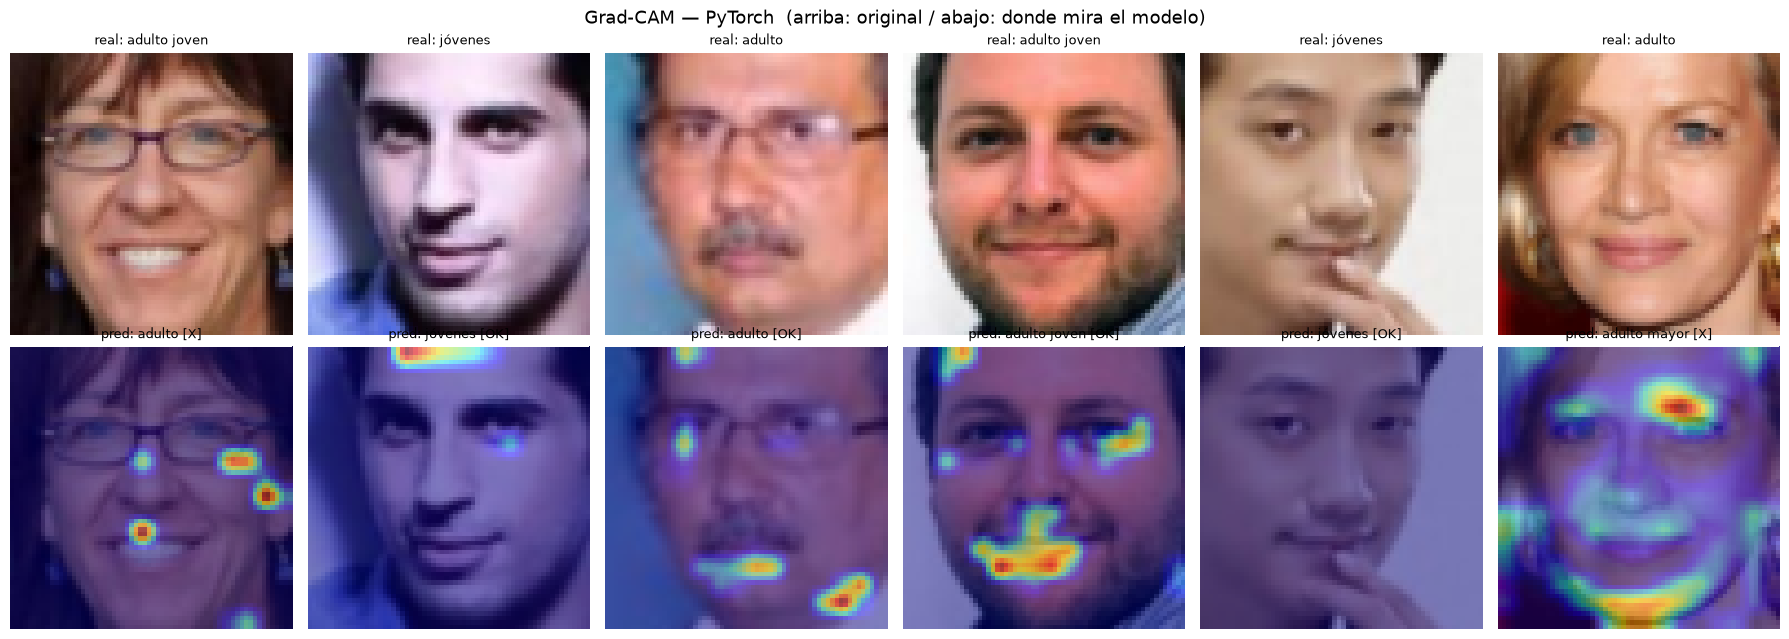

In [8]:
# --- Grad-CAM (PyTorch) ---
import matplotlib.cm as cm

# Grad-CAM engancha (hooks) la ULTIMA capa convolucional (conv3). Usa los gradientes de la
# clase predicha que llegan a esa capa para ponderar sus mapas de activacion: el resultado
# es un mapa de calor que muestra QUE ZONAS de la cara pesaron mas en la decision.
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out.detach()

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def __call__(self, x, class_idx=None):
        self.model.eval()
        logits = self.model(x)
        if class_idx is None:
            class_idx = int(logits.argmax(dim=1).item())
        self.model.zero_grad()
        logits[0, class_idx].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)   # promedio espacial por canal
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx

gradcam_pt = GradCAM(model_pt, model_pt.conv3)

def desnormalizar(img_tensor):
    # Revierte Normalize(mean=0.5, std=0.5) para volver a [0,1] y poder mostrar la imagen.
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)
    return np.clip(img * 0.5 + 0.5, 0, 1)

# Elegimos algunas imagenes del set de test (mismo random_state que Keras para comparar).
n_muestras = 6
sample = test_df.sample(n_muestras, random_state=SEED).reset_index(drop=True)

fig, axes = plt.subplots(2, n_muestras, figsize=(3 * n_muestras, 6.5))
for j in range(n_muestras):
    row = sample.iloc[j]
    img_t = transform(Image.open(row["filepath"]).convert("RGB")).unsqueeze(0).to(device)
    cam, pred = gradcam_pt(img_t)
    base = desnormalizar(img_t[0])

    axes[0, j].imshow(base)
    axes[0, j].set_title(f"real: {CLASS_NAMES[row['label']]}", fontsize=9)
    axes[0, j].axis("off")

    axes[1, j].imshow(base)
    axes[1, j].imshow(cam, cmap="jet", alpha=0.5)
    ok = "OK" if pred == row["label"] else "X"
    axes[1, j].set_title(f"pred: {CLASS_NAMES[pred]} [{ok}]", fontsize=9)
    axes[1, j].axis("off")

fig.suptitle("Grad-CAM — PyTorch  (arriba: original / abajo: donde mira el modelo)", fontsize=13)
plt.tight_layout()
plt.show()

## 3. Parte B — TensorFlow/Keras

Entrenamos la CNN equivalente en Keras y repetimos el Grad-CAM.

In [9]:
import tensorflow as tf

def load_and_preprocess(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img, label

def make_tf_dataset(dataframe, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((dataframe["filepath"].values, dataframe["label"].values))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds_tf = make_tf_dataset(train_df, shuffle=True)
val_ds_tf = make_tf_dataset(val_df)
test_ds_tf = make_tf_dataset(test_df)

In [10]:
# --- Arquitectura CNN equivalente, en Keras ---
model_tf = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    tf.keras.layers.Conv2D(16, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(CLASS_NAMES), activation="softmax"),
])

model_tf.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model_tf.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 548,645 (2.09 MB)

 Trainable params: 548,645 (2.09 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# --- Entrenamiento (Keras) ---
EPOCHS_TF = 10
t_inicio_tf = time.time()
history_tf = model_tf.fit(train_ds_tf, validation_data=val_ds_tf, epochs=EPOCHS_TF)
t_total_tf = time.time() - t_inicio_tf

print(f"\nTiempo total de entrenamiento (Keras): {t_total_tf:.2f} segundos")

Epoch 1/10


c:\Users\fsali\Documents\GitHub\frameworks-ia-2026_udd\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.2696 - loss: 1.5795 - val_accuracy: 0.3598 - val_loss: 1.4694
Epoch 2/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4281 - loss: 1.3316 - val_accuracy: 0.4675 - val_loss: 1.2733
Epoch 3/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4887 - loss: 1.2012 - val_accuracy: 0.4980 - val_loss: 1.1788
Epoch 4/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5274 - loss: 1.1222 - val_accuracy: 0.5224 - val_loss: 1.1446
Epoch 5/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5584 - loss: 1.0560 - val_accuracy: 0.5203 - val_loss: 1.1594
Epoch 6/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5993 - loss: 0.9924 - val_accuracy: 0.5203 - val_loss: 1.1900
Epoch 7/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6154 - loss: 0.9386 - val_accuracy: 0.5386 - val_loss: 1.0790
Epoch 8/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6524 - loss: 0.8558 - val_accuracy: 0.5589 - val_loss: 1.

### Grad-CAM con Keras

Con `tf.GradientTape` obtenemos los gradientes de la clase predicha respecto a la salida de la
última capa `Conv2D`. Se usan **las mismas imágenes** que en PyTorch para poder comparar
dónde mira cada framework.

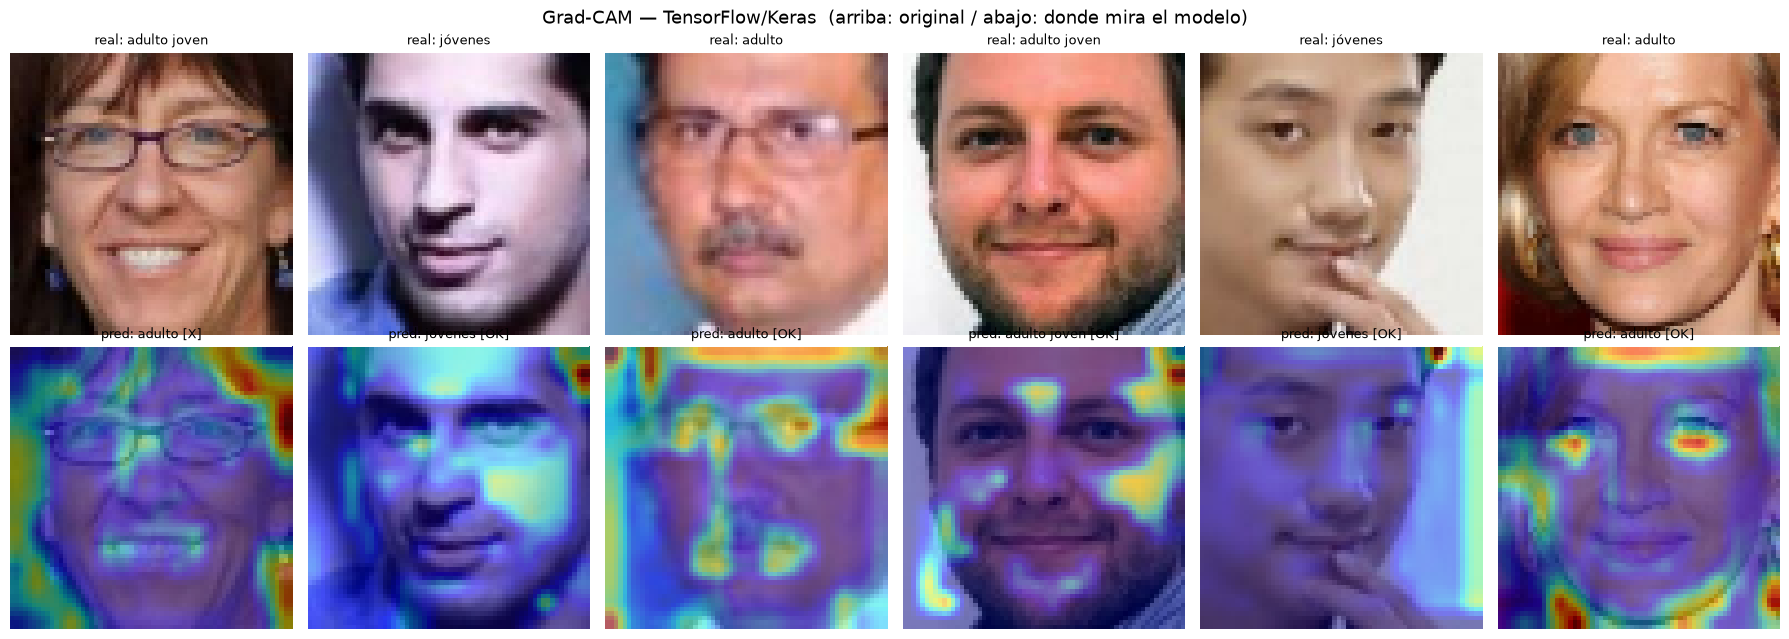

In [12]:
# --- Grad-CAM (Keras) ---
# Reconstruimos el forward de forma funcional (compatible con Keras 3) para poder capturar la
# salida de la ULTIMA capa convolucional. grad_model devuelve (mapa_conv, predicciones).
inp = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = inp
conv_output = None
for layer in model_tf.layers:
    x = layer(x)
    if isinstance(layer, tf.keras.layers.Conv2D):
        conv_output = x   # nos quedamos con la ultima conv (el bucle la va sobreescribiendo)
grad_model = tf.keras.models.Model(inp, [conv_output, x])

def gradcam_keras(img_array, class_idx=None):
    x = tf.convert_to_tensor(img_array[None, ...], dtype=tf.float32)
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(x)
        if class_idx is None:
            class_idx = int(tf.argmax(preds[0]))
        loss = preds[:, class_idx]
    grads = tape.gradient(loss, conv_out)
    weights = tf.reduce_mean(grads, axis=(0, 1, 2))          # promedio espacial por canal
    cam = tf.reduce_sum(conv_out[0] * weights, axis=-1)
    cam = tf.nn.relu(cam)
    cam = tf.image.resize(cam[..., tf.newaxis], (IMG_SIZE, IMG_SIZE)).numpy().squeeze()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam, class_idx

def cargar_img_tf(filepath):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0
    return img.numpy()

# Usamos las MISMAS imagenes que en PyTorch (mismo random_state) para comparar frameworks.
sample = test_df.sample(6, random_state=SEED).reset_index(drop=True)
n_muestras = len(sample)

fig, axes = plt.subplots(2, n_muestras, figsize=(3 * n_muestras, 6.5))
for j in range(n_muestras):
    row = sample.iloc[j]
    img = cargar_img_tf(row["filepath"])
    cam, pred = gradcam_keras(img)

    axes[0, j].imshow(img)
    axes[0, j].set_title(f"real: {CLASS_NAMES[row['label']]}", fontsize=9)
    axes[0, j].axis("off")

    axes[1, j].imshow(img)
    axes[1, j].imshow(cam, cmap="jet", alpha=0.5)
    ok = "OK" if pred == row["label"] else "X"
    axes[1, j].set_title(f"pred: {CLASS_NAMES[pred]} [{ok}]", fontsize=9)
    axes[1, j].axis("off")

fig.suptitle("Grad-CAM — TensorFlow/Keras  (arriba: original / abajo: donde mira el modelo)", fontsize=13)
plt.tight_layout()
plt.show()

#### ¿Cómo se lee el heatmap?
- **Rojo / cálido:** regiones que más pesaron en la predicción.
- **Azul / frío:** regiones casi ignoradas.

## Conclusión y comparación de frameworks

### 1. ¿Por qué PyTorch y Keras dan resultados (y heatmaps) distintos?
Aunque entrenamos **la misma arquitectura con las mismas imágenes**, cada framework parte y procesa de forma distinta:

- **Inicialización de pesos:** PyTorch y Keras usan esquemas de inicialización por defecto diferentes, así que cada modelo arranca desde un punto distinto del espacio de parámetros y converge a una solución distinta.
- **Preprocesamiento y normalización:** las imágenes se normalizan con escalas/estadísticas distintas en cada pipeline, por lo que los modelos ven **distribuciones de entrada diferentes**.
- **Augmentación:** las transformaciones (y su aleatoriedad) no son idénticas, lo que cambia qué ejemplos ve cada red durante el entrenamiento.

Todo esto hace que los pesos finales —y por lo tanto los mapas de Grad-CAM— no tengan por qué coincidir.

### Lo importante: ninguno es "mejor", son distintos y ambos funcionan
Pese a esas diferencias, **ambos frameworks llegan a accuracys muy parecidas** entrenando con las mismas imágenes. Esa es la señal clave: **no hay un framework superior al otro**, simplemente llegan por caminos distintos a un desempeño equivalente. Los dos funcionan.

### 2. Cómo interpretar el heatmap
El mapa de calor muestra **dónde quedó mirando el modelo al final**, pero eso **no significa que haya extraído toda la información desde ahí** — es un indicador de atención, no una explicación completa del razonamiento del modelo.

Aun así, es revelador comparar aciertos y errores:
- En los casos donde **acertó**, el calor se concentra en **rasgos del rostro** (ojos, frente, mejillas, contorno), justo donde está la información de la edad.
- En los casos donde **se equivocó**, el modelo tiende a quedarse "pegado" en el **fondo** o en zonas que no aportan información relevante — se apoyó en pistas espurias y por eso falló.
